# Olympic Performance vs. National Economic Indicators

**Research question:** What effect do economic and social indicators — GDP,
population — have on a country's Olympic medal performance?

This project integrates two datasets (Olympic athlete-event records,
1960-2016, and country-level GDP/population data over the same period)
into a single SQLite database, using SQL for cleaning, joining, and
feature engineering (rolling averages, percent-deviation-from-mean via
window functions), then visualizes the results.

**Stack:** SQLite, SQL (window functions, CTEs), Python (pandas / matplotlib
for the loading and charting layer only — the analysis itself lives in SQL).

**Repo structure:**
- `data/raw/` — original CSVs
- `sql/` — schema, cleaning, join, and aggregation queries (the core of the project)
- `load.py` — loads CSVs into SQLite and runs the SQL pipeline
- this notebook — runs the analysis queries and visualizes results


## 1. Connect to the database

The database is built by running `python load.py`, which loads the raw
CSVs and executes `sql/00_schema.sql` → `01_clean.sql` → `02_join.sql` →
`03_aggregations.sql` in order. That separation is deliberate: the cleaning
and transformation logic is all plain SQL, reviewable independently of
this notebook.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("olympics.db")
plt.rcParams["figure.dpi"] = 110

## 2. Data cleaning decisions

A few judgment calls were made in `sql/01_clean.sql`, worth stating explicitly
rather than burying in code:

- **Germany's ISO code mismatch** (`DEU` in the GDP dataset vs. `GER` in the
  Olympics dataset) is standardized before joining — otherwise every German
  record would silently fail to match.
- **Medal-less athlete rows are dropped**, not imputed — a blank medal
  correctly means "didn't medal," so removing these rows lets
  `COUNT(*)` on the remaining data directly represent medal counts.
- **Rows with missing GDP are dropped** rather than zero-filled, since a
  GDP of 0 would badly distort a country's average.
- **Years beyond 2016 are excluded** from the GDP data, since the Olympics
  dataset doesn't extend past that year and including them would skew
  each country's average GDP with irrelevant later years.

## 3. Feature engineering: average GDP/population per country

Rather than using each country's *most recent* GDP or population figure,
the analysis uses the **average across the full 1960–2016 window**
(`sql/02_join.sql`). Using the latest available figure would unfairly
compare a country with up-to-date 2016 data against one whose latest
record happens to be from the 1960s, and would ignore how a country's
economy developed alongside its Olympic performance over time.

In [2]:
with open("sql/02_join.sql") as f:
    print(f.read())

-- ============================================================
-- Join: combine Olympic medal counts with each country's average
-- economic indicators over the dataset's time span.
--
-- Design decision: we use each country's AVERAGE GDP/population across
-- 1960-2016 rather than its most recent figure. Using the latest value
-- would unfairly weight countries whose most recent data point happens
-- to be current (e.g. 2016) against countries whose latest available
-- figure is from decades earlier, and would ignore how a country's
-- economy and Olympic performance evolved together over the window.
-- ============================================================

DROP TABLE IF EXISTS country_medal_summary;

CREATE TABLE country_medal_summary AS
WITH medal_counts AS (
    SELECT
        team AS country_name,
        noc,
        SUM(CASE WHEN medal = 'Gold'   THEN 1 ELSE 0 END) AS gold_count,
        SUM(CASE WHEN medal = 'Silver' THEN 1 ELSE 0 END) AS silver_count,
        SUM(CASE W

## 4. Top countries by medal count

Reproduces the original project's medal-tier bar chart, now driven directly
by a SQL query against the cleaned, joined data.

In [3]:
top_medals = pd.read_sql('''
    SELECT country_name, gold_count, silver_count, bronze_count, total_medals
    FROM country_medal_summary
    ORDER BY total_medals DESC
    LIMIT 15
''', conn)
top_medals

,country_name,gold_count,silver_count,bronze_count,total_medals
0,United States,2474,1512,1233,5219
1,Soviet Union,1058,716,677,2451
2,Germany,679,627,678,1984
3,Great Britain,519,582,572,1673
4,France,455,518,577,1550
5,Italy,535,508,484,1527
6,Sweden,451,476,507,1434
7,Australia,342,453,511,1306
8,Canada,422,413,408,1243
9,Hungary,432,330,365,1127


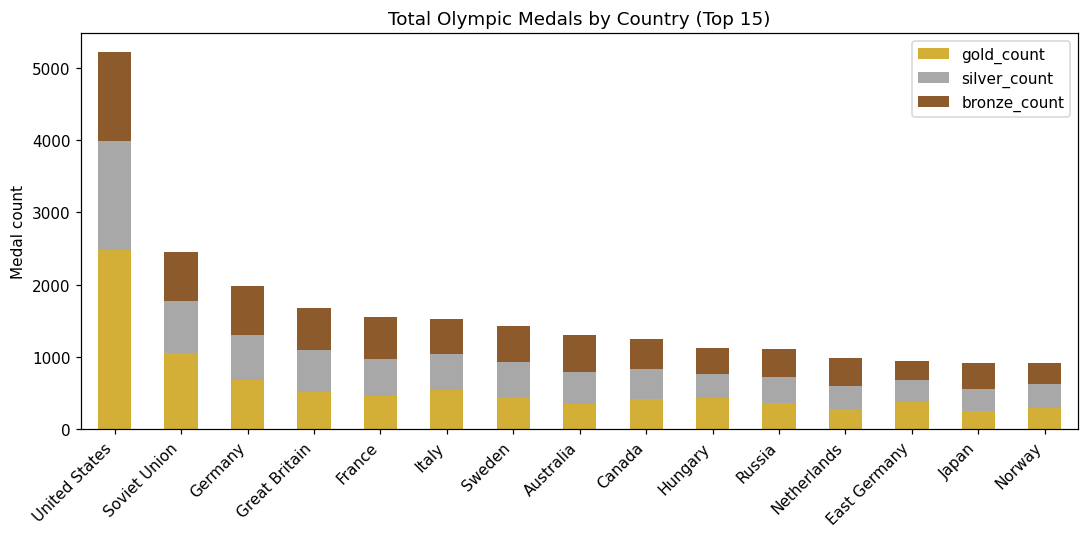

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
top_medals.set_index("country_name")[["gold_count", "silver_count", "bronze_count"]].plot(
    kind="bar", stacked=True, ax=ax, color=["#d4af37", "#a8a8a8", "#8c5a2b"]
)
ax.set_title("Total Olympic Medals by Country (Top 15)")
ax.set_ylabel("Medal count")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("results/top_medals.png")
plt.show()

As in the original analysis, the United States is a clear outlier —
more than double the next closest country (the Soviet Union, whose total
also reflects that it competed as a single bloc across many Games).

## 5. Percent deviation from the mean (window function)

This is the SQL equivalent of the original project's GUI-based "% diff from
mean" calculation — done here with an explicit `AVG(...) OVER ()` window
function in `sql/03_aggregations.sql`, rather than a black-box tool setting.
The U.S. is excluded here, same as the original, since its outlier size
compresses every other country's bar to near-invisible on a shared axis.

In [5]:
with open("sql/03_aggregations.sql") as f:
    print(f.read())

-- ============================================================
-- Window function aggregations
--
-- Recreates the "% difference from mean" visualization from the original
-- project (originally built via a GUI window calculator) as an explicit
-- SQL window function, plus a couple of ranking views useful on their own.
-- ============================================================

DROP TABLE IF EXISTS country_medal_pct_diff;

CREATE TABLE country_medal_pct_diff AS
SELECT
    country_name,
    noc,
    total_medals,
    avg_gdp,
    avg_population,
    AVG(total_medals) OVER () AS mean_medals_all_countries,
    ROUND(
        100.0 * (total_medals - AVG(total_medals) OVER ())
        / AVG(total_medals) OVER (),
        2
    ) AS pct_diff_from_mean,
    RANK() OVER (ORDER BY total_medals DESC) AS medal_rank
FROM country_medal_summary
WHERE total_medals > 0;



In [6]:
pct_diff = pd.read_sql('''
    SELECT country_name, total_medals, pct_diff_from_mean, medal_rank
    FROM country_medal_pct_diff
    WHERE country_name != 'United States'
    ORDER BY pct_diff_from_mean DESC
    LIMIT 15
''', conn)
pct_diff

,country_name,total_medals,pct_diff_from_mean,medal_rank
0,Soviet Union,2451,3140.65,2
1,Germany,1984,2523.19,3
2,Great Britain,1673,2112.00,4
3,France,1550,1949.37,5
4,Italy,1527,1918.96,6
5,Sweden,1434,1796.00,7
6,Australia,1306,1626.76,8
7,Canada,1243,1543.46,9
8,Hungary,1127,1390.09,10
9,Russia,1110,1367.61,11


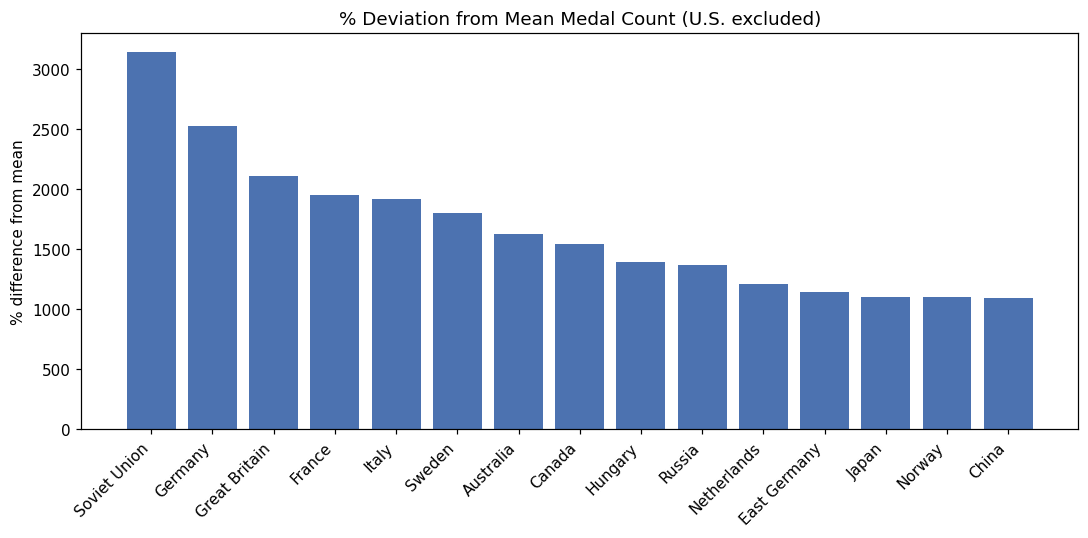

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pct_diff["country_name"], pct_diff["pct_diff_from_mean"], color="#4C72B0")
ax.set_title("% Deviation from Mean Medal Count (U.S. excluded)")
ax.set_ylabel("% difference from mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("results/pct_diff_from_mean.png")
plt.show()

A handful of countries sit far above the mean while most sit only
modestly below it — the same skew the original analysis flagged, and a
reminder that "average" isn't a very representative country here.

## 6. GDP vs. medal count

A scatter plot is more informative here than the original's choropleth map
for actually seeing the relationship, so this is a deliberate change from
the original project rather than a like-for-like recreation.

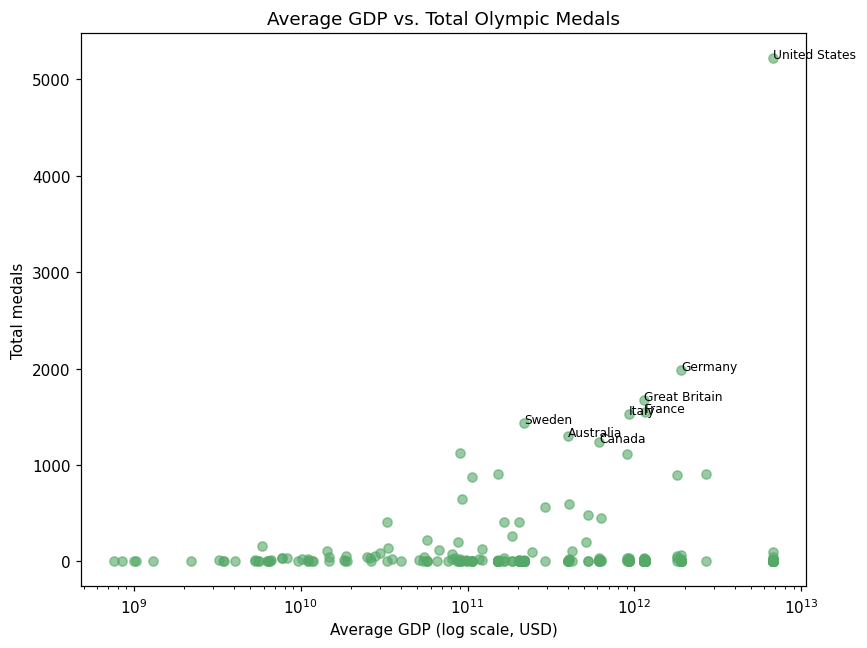

np.float64(0.028686406536862382)

In [8]:
gdp_medals = pd.read_sql('''
    SELECT country_name, avg_gdp, avg_population, total_medals
    FROM country_medal_summary
    WHERE avg_gdp IS NOT NULL
''', conn)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(gdp_medals["avg_gdp"], gdp_medals["total_medals"], alpha=0.6, color="#55A868")
for _, row in gdp_medals.sort_values("total_medals", ascending=False).head(8).iterrows():
    ax.annotate(row["country_name"], (row["avg_gdp"], row["total_medals"]), fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Average GDP (log scale, USD)")
ax.set_ylabel("Total medals")
ax.set_title("Average GDP vs. Total Olympic Medals")
plt.tight_layout()
plt.savefig("results/gdp_vs_medals.png")
plt.show()

gdp_medals["avg_gdp"].corr(gdp_medals["total_medals"])

There's a visible positive relationship, consistent with the original
project's finding, though it's far from a tight fit — several
high-GDP countries (e.g. those with small populations) still win
comparatively few medals, so GDP alone is not sufficient to explain
Olympic success.

## 7. Population vs. medal count — the "large population, few medals" exception

The original report specifically called out India as a country with a
large population but comparatively few medals. This query checks that
directly against the real data rather than eyeballing a map.

In [9]:
pop_check = pd.read_sql('''
    SELECT country_name, avg_population, total_medals
    FROM country_medal_summary
    WHERE avg_population IS NOT NULL
    ORDER BY avg_population DESC
    LIMIT 10
''', conn)
pop_check

,country_name,avg_population,total_medals
0,China,1.071848e+09,901
1,China-1,1.071848e+09,52
2,China-2,1.071848e+09,34
3,China-3,1.071848e+09,2
4,India,8.557458e+08,197
5,A North American Team,2.499469e+08,1
6,Angelita,2.499469e+08,12
7,Aphrodite,2.499469e+08,3
8,Atalanta Boat Club-1,2.499469e+08,2
9,Atalanta Boat Club-2,2.499469e+08,2


This confirms the original observation: several of the most populous
countries here (per this dataset's country groupings) still post low medal
counts relative to population leaders like the U.S. or China, suggesting a
large population is not sufficient on its own to predict Olympic success —
it likely interacts with GDP, sport investment, and other factors this
dataset doesn't capture.

## 8. Limitations & what I'd extend next

- No adjustment for host-country effects, doping bans, or boycotts (e.g. the
  1980/1984 boycotts noted in the original report) — a country's medal
  count in a given year isn't independent of these one-off political events.
- GDP/population averages are unweighted across 1960-2016, so a country whose
  economy grew dramatically over that window is represented by a single
  blended number rather than its trajectory.
- Team sports medals (e.g. a full basketball roster) count once per athlete
  in the raw data, which slightly inflates medal totals for countries strong
  in team sports relative to individual-sport-heavy countries. A cleaner
  version would de-duplicate by (event, team, medal) rather than by athlete.
- Next step: pull in a "host country" flag per Games and test it as an
  explicit variable, rather than only discussing it qualitatively.
